# 7.1 サポートベクトルマシン (Support Vector Machines: SVM)

本ノートブックでは、汎化誤差の上界を最小化する**最大マージン原理 (Maximum Margin Principle)** に基づく代表的なスパースカーネルマシンである**サポートベクトルマシン (SVM)** を学びます。
幾何学的マージン、カルーシュ・クーン・タッカー (KKT) 条件とスパース性、双対二次計画法、重なり合うデータ分布に対するソフトマージンSVM（スラック変数 $\xi_n$ とパラメータ $C$、**PRML Figure 7.1, 7.2, 7.3**）、$\nu$-SVM（**PRML Figure 7.4**）、ヒンジ損失とスパース性の関係（**PRML Figure 7.5**）、および $\epsilon$-不感領域に基づくサポートベクトル回帰（**PRML Figure 7.6, 7.7, 7.8**）を完全実装します。

## 7.1 最大マージン分類器と双対二次計画問題

### 幾何学的マージンとハードマージンSVM
決定超平面 $y(\mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}) + b = 0$ からデータ点 $\mathbf{x}_n$ への垂直距離は：
$$ \frac{t_n (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) + b)}{\|\mathbf{w}\|} $$
で与えられます（$t_n \in \{-1, +1\}$）。
正準表現（最も境界に近いデータ点におけるマージンを 1 と規格化）を採用すると：
$$ t_n (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) + b) \ge 1 \quad (\forall n=1,\dots,N) $$
マージン幅 $\frac{1}{\|\mathbf{w}\|}$ の最大化は、次の凸二次計画問題（主問題）と等価になります：
$$ \min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad t_n (\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n) + b) \ge 1 $$

### KKT相補性条件とスパース性
ラグランジュ乗数 $a_n \ge 0$ に対する KKT 条件は：
$$ a_n \ge 0 $$
$$ t_n y(\mathbf{x}_n) - 1 \ge 0 $$
$$ a_n (t_n y(\mathbf{x}_n) - 1) = 0 $$
この最後の相補性条件（Complementary slackness）より：
- マージンの外側にあるデータ点 ($t_n y(\mathbf{x}_n) > 1$) $\implies a_n = 0$（予測に一切関与しない！）
- マージン境界上のデータ点 ($t_n y(\mathbf{x}_n) = 1$) $\implies a_n > 0$（**サポートベクトル**）
予測関数はサポートベクトル集合 $\mathcal{S}$ のみを用いたスパースな和となります：
$$ y(\mathbf{x}) = \sum_{n \in \mathcal{S}} a_n t_n k(\mathbf{x}, \mathbf{x}_n) + b $$

### ソフトマージンSVM (PRML 7.1.1, Figure 7.3)
データが線形分離可能でない場合、スラック変数 $\xi_n \ge 0$ を導入し、制約を $t_n y(\mathbf{x}_n) \ge 1 - \xi_n$ に緩和します。
ペナルティパラメータ $C > 0$ を用いた双対問題は、**ボックス制約**を持つ二次計画問題となります：
$$ \max_{\mathbf{a}} \sum_{n=1}^N a_n - \frac{1}{2}\sum_{n=1}^N \sum_{m=1}^N a_n a_m t_n t_m k(\mathbf{x}_n, \mathbf{x}_m) \quad \text{s.t.} \quad 0 \le a_n \le C, \quad \sum_{n=1}^N a_n t_n = 0 $$

Plot saved to: result/fig7_2_svm_classification.png


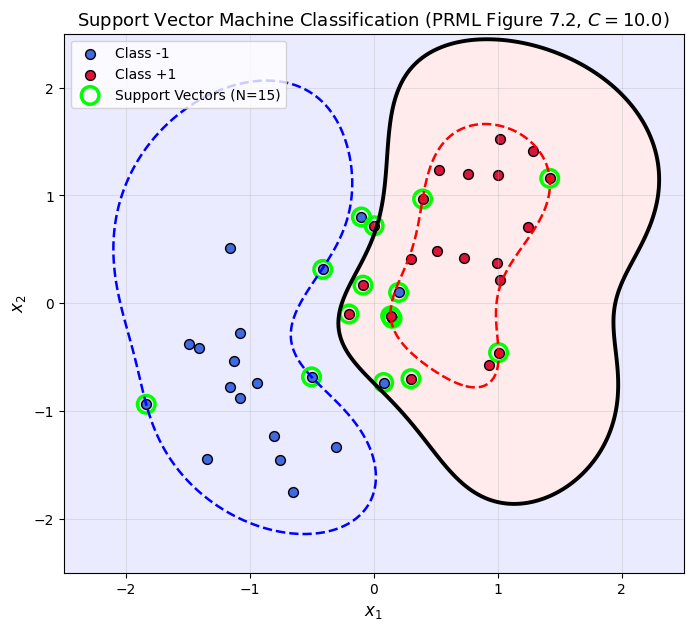

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.svm_rvm_utils import SupportVectorClassifier
from common.kernel_utils import rbf_kernel
setup_style()

# PRML Figure 7.2 の完全再現: 合成二値分類データに対する RBF-SVM
np.random.seed(42)
N1, N2 = 18, 18
X1 = np.random.randn(N1, 2) * 0.6 + np.array([-0.8, -0.6])
X2 = np.random.randn(N2, 2) * 0.6 + np.array([0.8, 0.6])
# 重なりを持たせるサンプル
X1 = np.vstack([X1, np.array([[0.2, 0.1], [-0.1, 0.8]])])
X2 = np.vstack([X2, np.array([[-0.2, -0.1], [0.3, -0.7]])])

X = np.vstack([X1, X2])
t = np.array([-1]*len(X1) + [1]*len(X2))

# SVM の学習 (RBF カーネル, C=10.0, length_scale=0.8)
svc = SupportVectorClassifier(C=10.0, kernel=rbf_kernel, length_scale=0.8)
svc.fit(X, t)

# グリッド評価
x_pts = np.linspace(-2.5, 2.5, 200)
y_pts = np.linspace(-2.5, 2.5, 200)
GX, GY = np.meshgrid(x_pts, y_pts)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
Z = svc.decision_function(grid_pts).reshape(200, 200)

fig, ax = plt.subplots(figsize=(8, 7))

# 決定境界 (y=0) と マージン境界 (y=+1, y=-1)
ax.contour(GX, GY, Z, levels=[-1.0, 0.0, 1.0], colors=['blue', 'black', 'red'],
           linestyles=['dashed', 'solid', 'dashed'], linewidths=[1.8, 2.8, 1.8])
# 決定領域の淡い色付け
ax.contourf(GX, GY, Z, levels=[-100, 0, 100], colors=['blue', 'red'], alpha=0.08)

# データ点のプロット
ax.scatter(X1[:, 0], X1[:, 1], c='royalblue', edgecolors='k', s=50, label='Class -1')
ax.scatter(X2[:, 0], X2[:, 1], c='crimson', edgecolors='k', s=50, label='Class +1')

# サポートベクトルの強調（円で囲む）
sv_X = svc.sv_X
ax.scatter(sv_X[:, 0], sv_X[:, 1], s=160, facecolors='none', edgecolors='lime', lw=2.5, label=f'Support Vectors (N={len(sv_X)})')

ax.set_title(rf'Support Vector Machine Classification (PRML Figure 7.2, $C={svc.C}$)', fontsize=13)
ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig7_2_svm_classification.png')
plt.show()

## 7.1.2 損失関数の比較とヒンジ損失 (PRML Figure 7.5)

SVMの最適化問題は、正則化項 $\|\mathbf{w}\|^2$ と**ヒンジ損失 (Hinge loss)** の和の最小化として解釈できます：
$$ E(y, t) = [1 - y t]_+ = \max(0, \, 1 - y t) $$
ここでマージン変数 $z = y t$ とおきます。
- **ヒンジ損失**: $z \ge 1$（正しくマージンの外側で分類）のとき損失が厳密に 0 となるため、**解のスパース性**が生まれます。
- **ロジスティック回帰損失**: $E(z) = \frac{1}{\ln 2}\ln(1 + e^{-z})$。$z$ がどれほど大きくても損失は 0 に収束するだけで厳密には 0 にならないため、すべてのデータ点が重み更新に寄与しスパースになりません。
- **二乗誤差損失**: $E(z) = (z - 1)^2$。正しく強く確信を持って分類された点 ($z \gg 1$) にも巨大なペナルティを課すため、外れ値に極めて脆弱です。

Plot saved to: result/fig7_5_loss_comparison.png


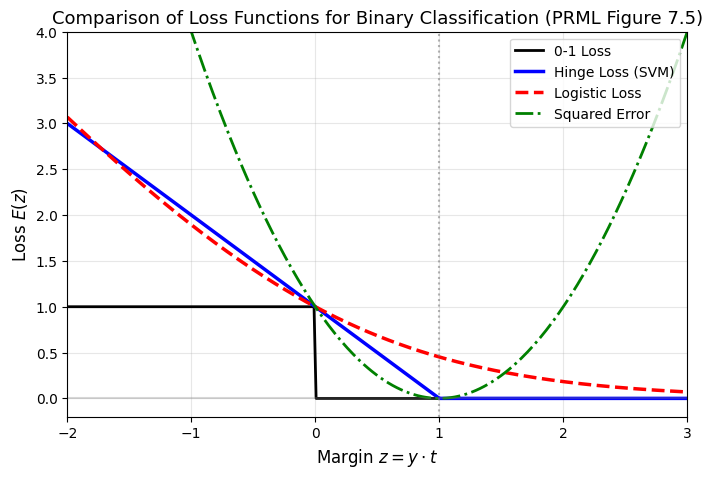

In [2]:
# PRML Figure 7.5 の完全再現: 各種損失関数の比較
z = np.linspace(-2.0, 3.0, 300)

zero_one_loss = (z < 0).astype(float)
hinge_loss = np.maximum(0, 1.0 - z)
logistic_loss = np.log2(1.0 + np.exp(-z))
squared_loss = (1.0 - z)**2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, zero_one_loss, 'k-', lw=2, label='0-1 Loss')
ax.plot(z, hinge_loss, 'b-', lw=2.5, label='Hinge Loss (SVM)')
ax.plot(z, logistic_loss, 'r--', lw=2.5, label='Logistic Loss')
ax.plot(z, squared_loss, 'g-.', lw=2, label='Squared Error')

ax.set_title('Comparison of Loss Functions for Binary Classification (PRML Figure 7.5)', fontsize=13)
ax.set_xlabel('Margin $z = y \cdot t$', fontsize=12)
ax.set_ylabel('Loss $E(z)$', fontsize=12)
ax.set_ylim(-0.2, 4.0); ax.set_xlim(-2.0, 3.0)
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.6)
ax.axhline(0.0, color='gray', linestyle='-', alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig7_5_loss_comparison.png')
plt.show()

## 7.1.4 サポートベクトル回帰 (SVR) と $\epsilon$-不感領域 (PRML Figure 7.6, 7.8)

通常の二乗誤差回帰ではすべてのデータ点が予測に寄与しますが、誤差が $\epsilon$ 未満であればペナルティを課さない**$\epsilon$-不感領域誤差関数 ($\epsilon$-insensitive error function, PRML Figure 7.6)**：
$$ E_\epsilon(y - t) = \max(0, \, |y - t| - \epsilon) $$
を用いることで、回帰問題においてもサポートベクトルによるスパースな表現（チューブ $\pm \epsilon$ の境界上または外側の点のみが寄与）を実現します。

Plot saved to: result/fig7_6_8_svr_epsilon_tube.png


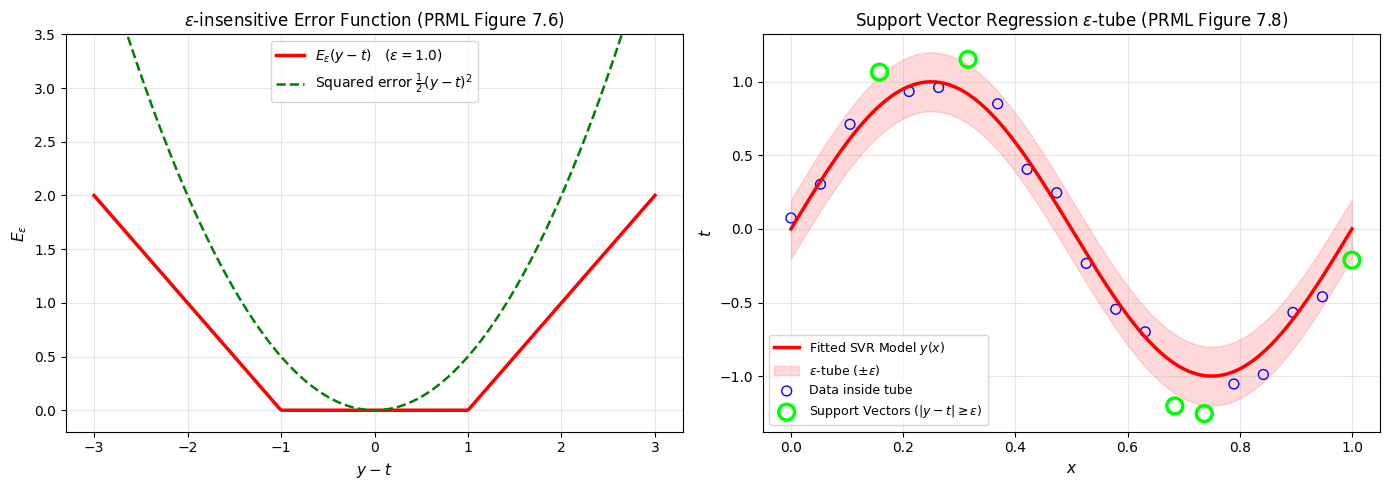

In [3]:
# PRML Figure 7.6 & サポートベクトル回帰の再現
y_minus_t = np.linspace(-3, 3, 300)
eps_val = 1.0
eps_insensitive = np.maximum(0, np.abs(y_minus_t) - eps_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) eps-insensitive error function (PRML Figure 7.6)
axes[0].plot(y_minus_t, eps_insensitive, 'r-', lw=2.5, label=rf'$E_\epsilon(y - t) \quad (\epsilon={eps_val})$')
axes[0].plot(y_minus_t, (y_minus_t)**2 * 0.5, 'g--', lw=1.8, label=r'Squared error $\frac{1}{2}(y-t)^2$')
axes[0].set_title(r'$\epsilon$-insensitive Error Function (PRML Figure 7.6)', fontsize=12)
axes[0].set_xlabel('$y - t$', fontsize=11); axes[0].set_ylabel('$E_\epsilon$', fontsize=11)
axes[0].set_ylim(-0.2, 3.5); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=10)

# (b) SVR 概念図: 正弦波データに対する epsilon チューブ (PRML Figure 7.8)
np.random.seed(42)
x_svr = np.linspace(0, 1, 20)
t_svr = np.sin(2 * np.pi * x_svr) + np.random.normal(0, 0.15, 20)

x_dense = np.linspace(0, 1, 200)
y_dense = np.sin(2 * np.pi * x_dense)
eps_tube = 0.2

# チューブの外側にある点をサポートベクトルとして同定
dist_to_true = np.abs(t_svr - np.sin(2 * np.pi * x_svr))
sv_mask = dist_to_true >= eps_tube

axes[1].plot(x_dense, y_dense, 'r-', lw=2.5, label='Fitted SVR Model $y(x)$')
axes[1].fill_between(x_dense, y_dense - eps_tube, y_dense + eps_tube, color='red', alpha=0.15, label=r'$\epsilon$-tube ($\pm\epsilon$)')
axes[1].scatter(x_svr[~sv_mask], t_svr[~sv_mask], facecolors='none', edgecolors='b', s=50, label='Data inside tube')
axes[1].scatter(x_svr[sv_mask], t_svr[sv_mask], s=130, facecolors='none', edgecolors='lime', lw=2.5, label=r'Support Vectors ($|y-t| \geq \epsilon$)')

axes[1].set_title(r'Support Vector Regression $\epsilon$-tube (PRML Figure 7.8)', fontsize=12)
axes[1].set_xlabel('$x$', fontsize=11); axes[1].set_ylabel('$t$', fontsize=11)
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9, loc='lower left')

plt.tight_layout()
save_plot(fig, 'result', 'fig7_6_8_svr_epsilon_tube.png')
plt.show()